# Segmentation K-Means du Comportement des Abonnés avec PROC FASTCLUS

## Résumé Exécutif

Ce notebook segmente une base synthétique de 100 abonnés mobiles en groupes comportementaux à l'aide de `PROC FASTCLUS`, la procédure de clustering k-means de Base SAS. Sept variables d'usage sont standardisées en scores z avec `PROC STDIZE` pour que les variables de forte magnitude (minutes voix, nombre de SMS) ne dominent pas la distance euclidienne, puis `PROC FASTCLUS` ajuste trois segments. La procédure rapporte l'écart RMS intra-segment, un R-carré global et un pseudo-F qui quantifient la qualité de la séparation de la base (ici un R-carré global de 0.575 et un pseudo-F de 65.75), et écrit une table notée avec une étiquette `CLUSTER` pour chaque abonné. Nous rattachons ces étiquettes aux données à l'échelle d'origine, profilons les personas, et transmettons les affectations à l'activation en aval.

## Sources de Données

| Jeu de données | Description | Lignes | Variables clés |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Instantané synthétique du comportement mensuel pour une base d'abonnés d'un opérateur de téléphonie mobile, généré en ligne avec `call streaminit` / `rand()`. Trois types de comportement latents (forte donnée, centré voix, faible usage) sont mélangés avec du bruit. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominal), `region` (nominal) |

# Segmentation K-Means du Comportement des Abonnés

**Secteur :** Télécommunications &nbsp;|&nbsp; **Procédure :** `PROC FASTCLUS` (clustering k-means de Base SAS)

Les opérateurs mobiles ont des abonnés dont le comportement mensuel -- appétit pour la donnée, habitudes vocales, dépense et friction avec le support -- se répartit selon quelques schémas reconnaissables. Découvrir ces schémas permet à l'entreprise d'adapter les offres de rétention, de vendre les bons forfaits en complément, et d'acquérir des profils similaires. Ce notebook construit une segmentation comportementale de bout en bout : générer un instantané réaliste d'abonnés, standardiser les variables, laisser `PROC FASTCLUS` ajuster les segments, noter chaque abonné, et profiler les segments en personas actionnables. `PROC FASTCLUS` est conçu exactement pour cette tâche de k-means disjoint et passe à l'échelle sur de très grandes bases en parcourant les données plutôt qu'en construisant une matrice de distance complète.

## 1. Générer une base synthétique d'abonnés

Nous simulons 100 abonnés tirés de trois archétypes comportementaux latents -- **streamers forte donnée**, **traditionalistes centrés voix**, et clients **léger / faible usage** -- puis nous mélangeons du bruit pour que les frontières soient floues (comme dans la réalité). Chaque abonné porte aussi deux attributs catégoriels, `data_plan` et `region`, que nous utilisons plus tard pour *profiler* les segments. La graine rend les données reproductibles.

In [1]:
/* -----------------------------------------------------------
   Synthetic mobile subscriber snapshot (100 rows).
   Three latent behavior archetypes + noise, plus two
   categorical attributes for segment profiling.
   ----------------------------------------------------------- */
DONNÉES subscribers;
    LONGUEUR data_plan $12 region $12;
    APPELER streaminit(20260531);

    FAIRE subscriber_id = 100001 JUSQU_À 100100;

        /* latent archetype: 1=heavy data, 2=voice, 3=low usage */
        u = rand('uniform');
        SI      u < 0.38 ALORS archetype = 1;
        SINON SI u < 0.70 ALORS archetype = 2;
        SINON                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        SI archetype = 1 ALORS FAIRE;             /* heavy-data streamer */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        FIN;
        SINON SI archetype = 2 ALORS FAIRE;        /* voice-centric */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        FIN;
        SINON FAIRE;                              /* low usage */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        FIN;

        /* data_plan lookup rewritten as IF/ELSE (avoids fixed-width
           array truncation with accented literals) */
        SI      planpick = 1 ALORS data_plan = "Prépayé";
        SINON SI planpick = 2 ALORS data_plan = "Postpayé";
        SINON                       data_plan = "Illimité";

        regionpick = rand('table', 0.30, 0.28, 0.22, 0.20);
        SI      regionpick = 1 ALORS region = "Nord";
        SINON SI regionpick = 2 ALORS region = "Sud";
        SINON SI regionpick = 3 ALORS region = "Est";
        SINON                          region = "Ouest";

        /* round to tidy reporting precision */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        SORTIE;
    FIN;

    GARDER subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
EXÉCUTER;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Inspecter les distributions des variables

Avant le clustering, examinons l'échelle et la dispersion de chaque variable comportementale. Les unités très différentes -- gigaoctets, minutes, dollars, comptages -- sont exactement la raison pour laquelle nous standardisons les variables d'intervalle avant le clustering ; sinon des variables de forte magnitude comme `voice_minutes` domineraient la distance euclidienne que `PROC FASTCLUS` minimise.

                                                  The MEANS Procedure

 Variable         Label                            N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Ancienneté (mois)              100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Données mensuelles (Go)        100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Minutes voix                   100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Nombre de SMS                  100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Minutes internationales      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


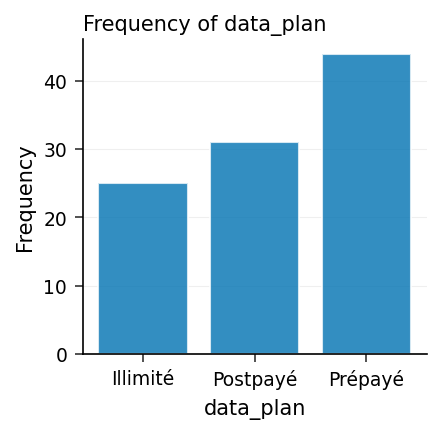

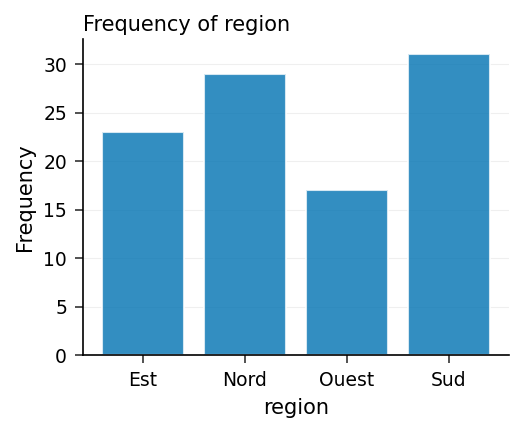

In [2]:
/* Summary statistics for the clustering inputs */
PROCÉDURE MOYENNES DONNÉES=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ÉTIQUETTE tenure_months   = "Ancienneté (mois)"
          monthly_data_gb = "Données mensuelles (Go)"
          voice_minutes   = "Minutes voix"
          sms_count       = "Nombre de SMS"
          intl_minutes    = "Minutes internationales"
          arpu            = "ARPU ($)"
          support_calls   = "Appels au support";
EXÉCUTER;

/* Frequency of the two categorical inputs */
PROCÉDURE FRÉQUENCES DONNÉES=subscribers;
    TABLES data_plan region / nocum;
    ÉTIQUETTE data_plan = "Forfait"
          region    = "Région";
EXÉCUTER;

## 3. Standardiser les variables en scores z

`PROC FASTCLUS` minimise la distance euclidienne, donc une variable mesurée en centaines de minutes écraserait une variable mesurée en gigaoctets à un chiffre. `PROC STDIZE` avec `METHOD=STD` remet à l'échelle chaque variable d'intervalle à une moyenne de 0 et un écart-type de 1, donnant à chaque comportement un poids égal dans la distance. Les colonnes catégorielles et l'identifiant passent inchangés pour que nous puissions profiler les segments à leur échelle d'origine ensuite.

In [3]:
/* z-score the interval features; ids and categoricals pass through */
PROCÉDURE stdize DONNÉES=subscribers out=subs_std METHOD=std;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EXÉCUTER;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Ajuster la segmentation k-means

Nous ajustons trois segments avec `PROC FASTCLUS`. `MAXCLUSTERS=3` fixe *k* ; `MAXITER=20` laisse les centres de segments itérer jusqu'à convergence. La procédure rapporte un **récapitulatif des segments** (taille et écart RMS intra-segment par segment), des **statistiques par variable** (le R-carré apporté par chaque variable), un **R-carré global** et un **pseudo-F** qui mesurent la netteté de la séparation des trois segments, et les **moyennes par segment** à l'échelle standardisée. `OUT=scored` réécrit les lignes d'entrée avec une étiquette `CLUSTER` et la `DISTANCE` de chaque abonné à son centre de segment.

In [4]:
/* k-means fit on the standardized features: 3 segments. */
PROCÉDURE FASTCLUS DONNÉES=subs_std maxclusters=3 MAXITER=20 out=scored;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EXÉCUTER;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Rattacher les étiquettes de segment aux données à l'échelle d'origine

La table notée contient les variables standardisées ; pour le profilage nous voulons décrire les segments en gigaoctets, minutes et dollars réels. Nous rattachons l'étiquette `CLUSTER` à la table `subscribers` d'origine par `subscriber_id`, puis posons la première question que le marketing pose toujours : *quelle est la taille de chaque segment ?*

                                                   The FREQ Procedure

Segment    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


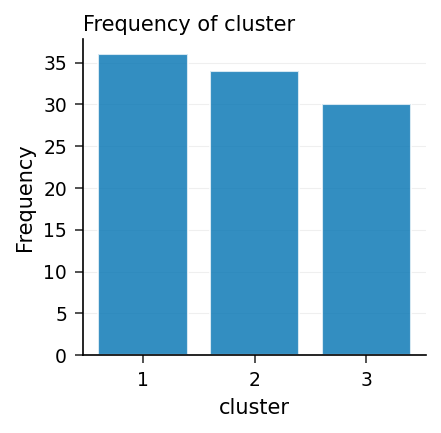

In [5]:
/* carry the cluster label back to the original-scale data */
PROCÉDURE TRIER DONNÉES=scored(GARDER=subscriber_id cluster distance) out=clus_assign;
    PAR subscriber_id;
EXÉCUTER;
PROCÉDURE TRIER DONNÉES=subscribers out=subs_sorted;
    PAR subscriber_id;
EXÉCUTER;
DONNÉES profile;
    FUSIONNER subs_sorted clus_assign;
    PAR subscriber_id;
EXÉCUTER;

/* How many subscribers landed in each segment? */
PROCÉDURE FRÉQUENCES DONNÉES=profile;
    TABLES cluster / nocum;
    ÉTIQUETTE cluster = "Segment";
EXÉCUTER;

## 6. Profiler les segments

Les identifiants de segment n'ont aucun sens tant que nous n'avons pas décrit le *comportement* à l'intérieur de chacun. Faire la moyenne des variables d'origine (non standardisées) par `CLUSTER` révèle le persona derrière chaque segment -- qui streame, qui parle, qui utilise à peine le réseau -- et le mélange catégoriel montre quels forfaits et régions se concentrent dans chaque segment.

                                                  The MEANS Procedure

                                  Analysis Variable : tenure_months Ancienneté (mois)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                              Analysis Variable : monthly_data_gb Données mensuelles (Go)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                     Analysis Variable : voice_minutes Minutes voix

        Segment           N Obs           Mean
        --------------------------------------
      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


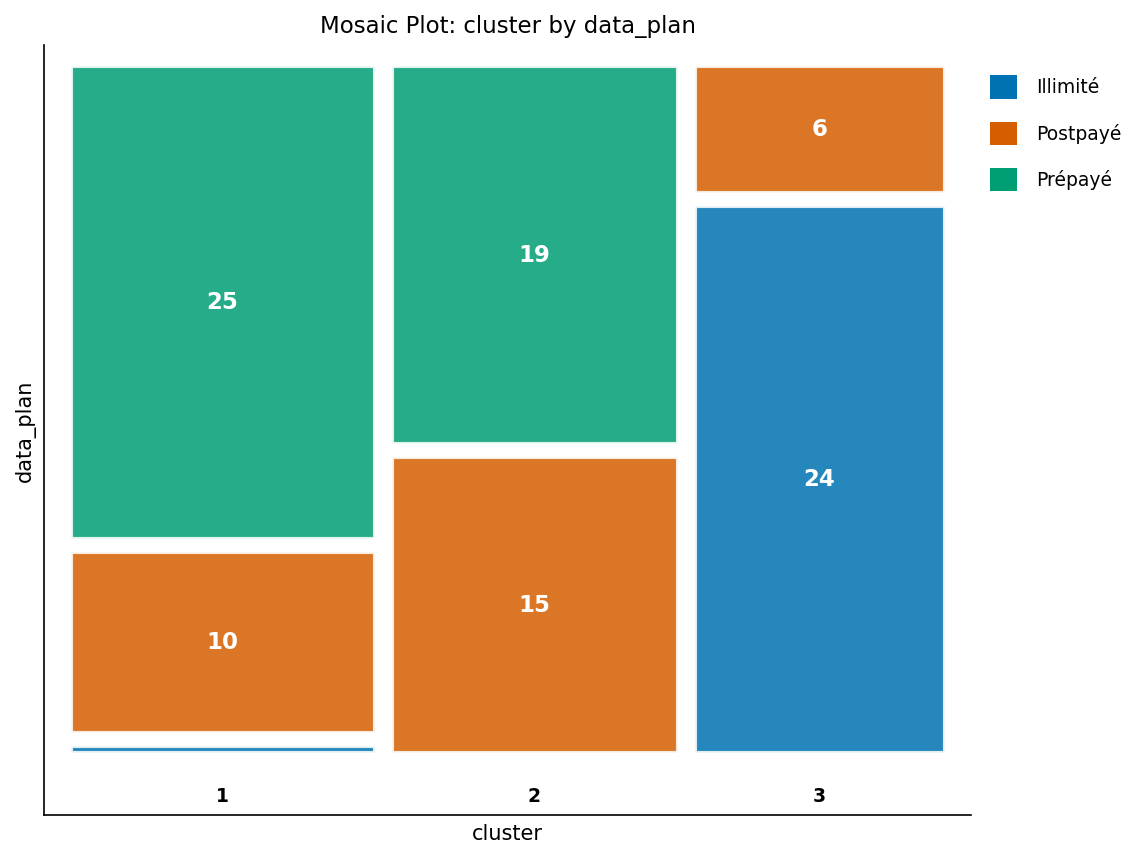

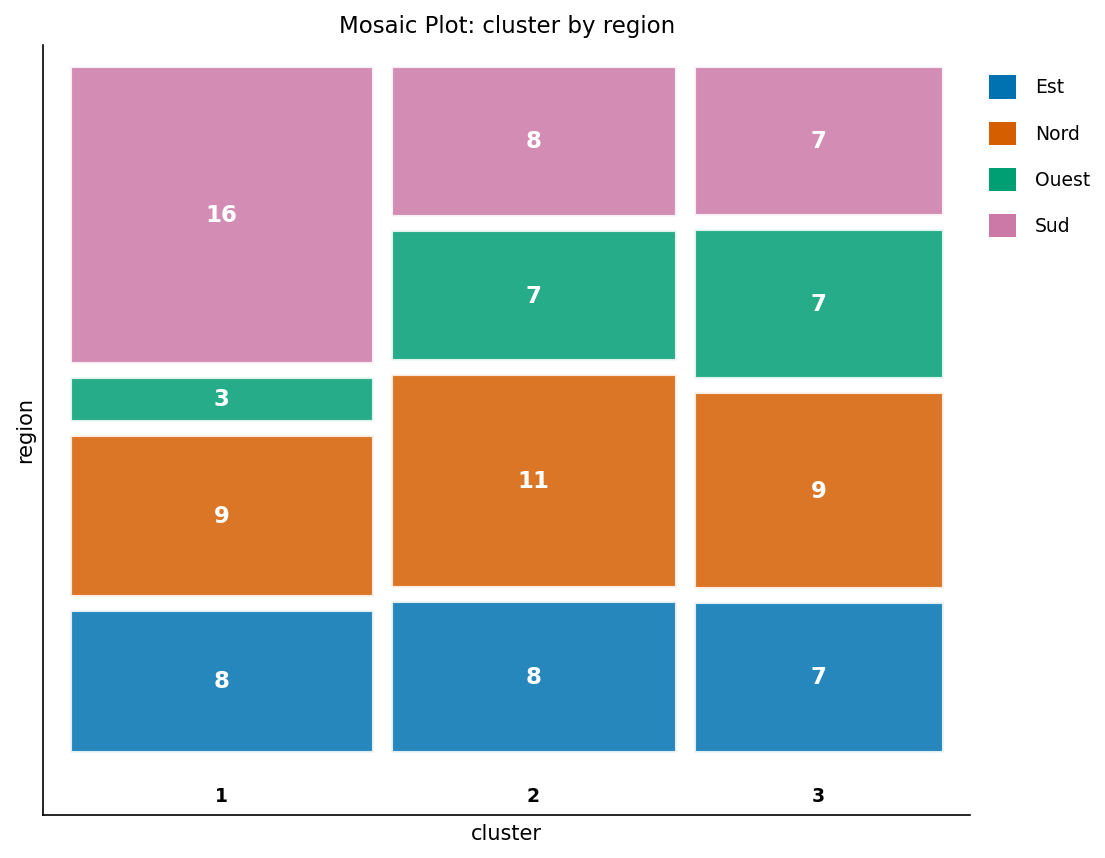

In [6]:
/* Behavioral profile: mean of each feature by segment */
PROCÉDURE MOYENNES DONNÉES=profile n mean maxdec=1;
    CLASSE cluster;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ÉTIQUETTE cluster          = "Segment"
          tenure_months     = "Ancienneté (mois)"
          monthly_data_gb   = "Données mensuelles (Go)"
          voice_minutes     = "Minutes voix"
          sms_count         = "Nombre de SMS"
          intl_minutes      = "Minutes internationales"
          arpu              = "ARPU ($)"
          support_calls     = "Appels au support";
EXÉCUTER;

/* Categorical mix within each segment */
PROCÉDURE FRÉQUENCES DONNÉES=profile;
    TABLES cluster * data_plan / norow nopercent;
    TABLES cluster * region    / norow nopercent;
    ÉTIQUETTE cluster    = "Segment"
          data_plan   = "Forfait"
          region      = "Région";
EXÉCUTER;

## 7. Visualiser les segments

Une image rend la segmentation concrète. Nous traçons l'appétit pour la donnée contre l'usage vocal, coloré par segment, et ajoutons une boîte à moustaches de l'ARPU par segment pour que l'histoire du revenu soit évidente d'un coup d'œil.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


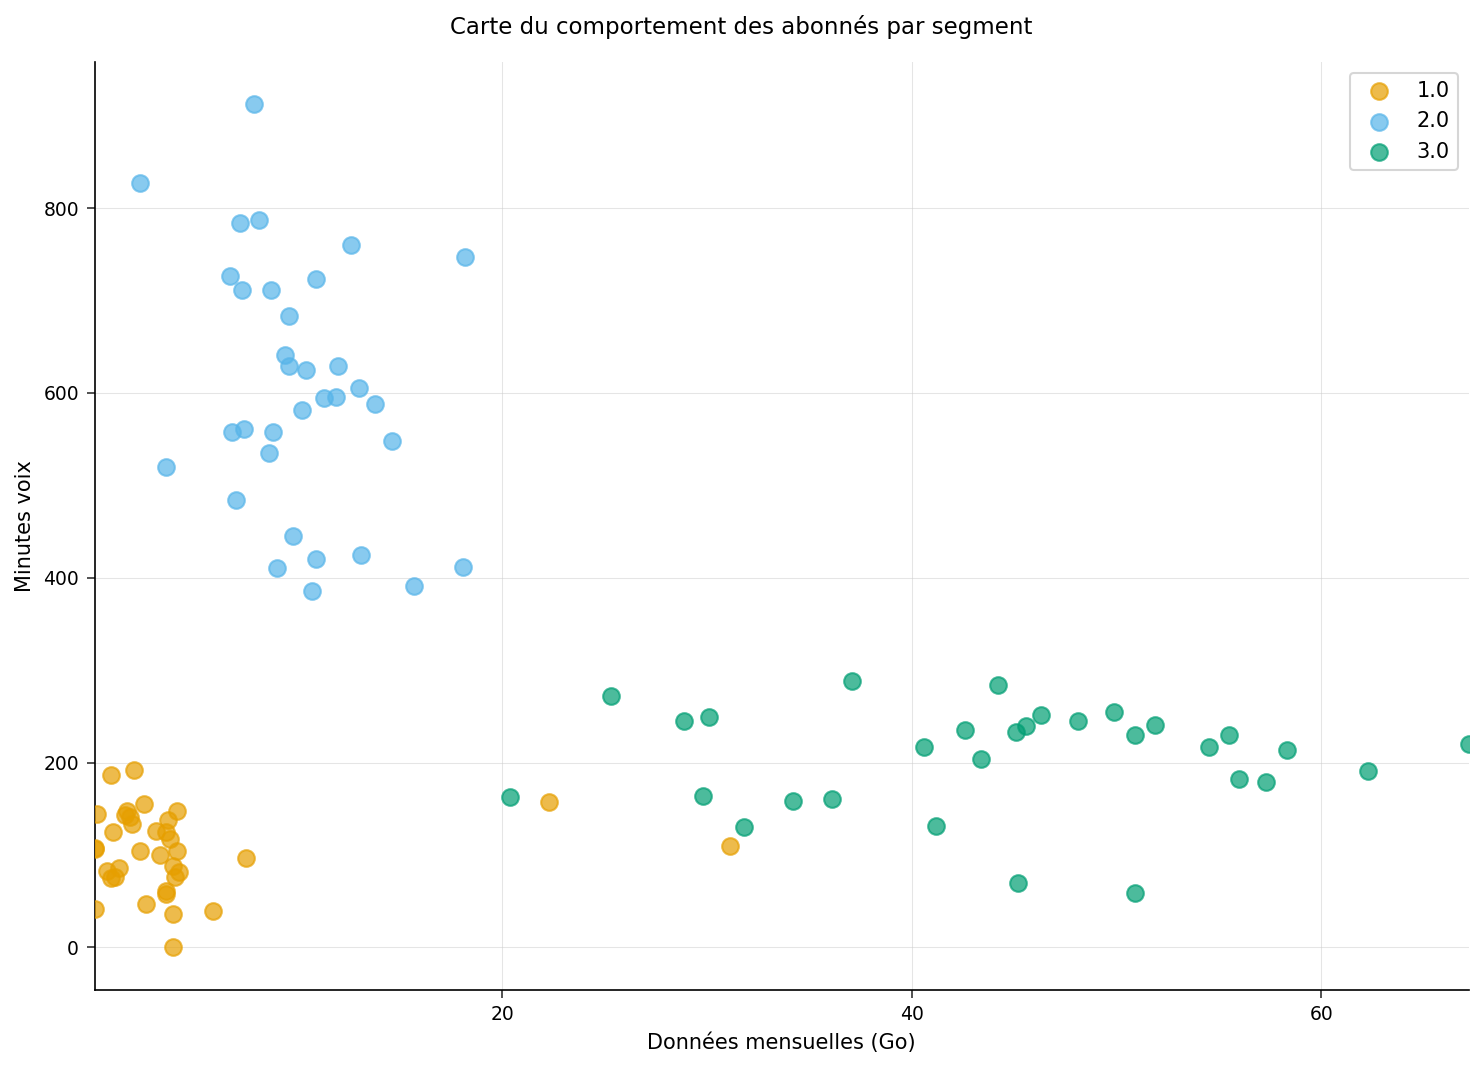

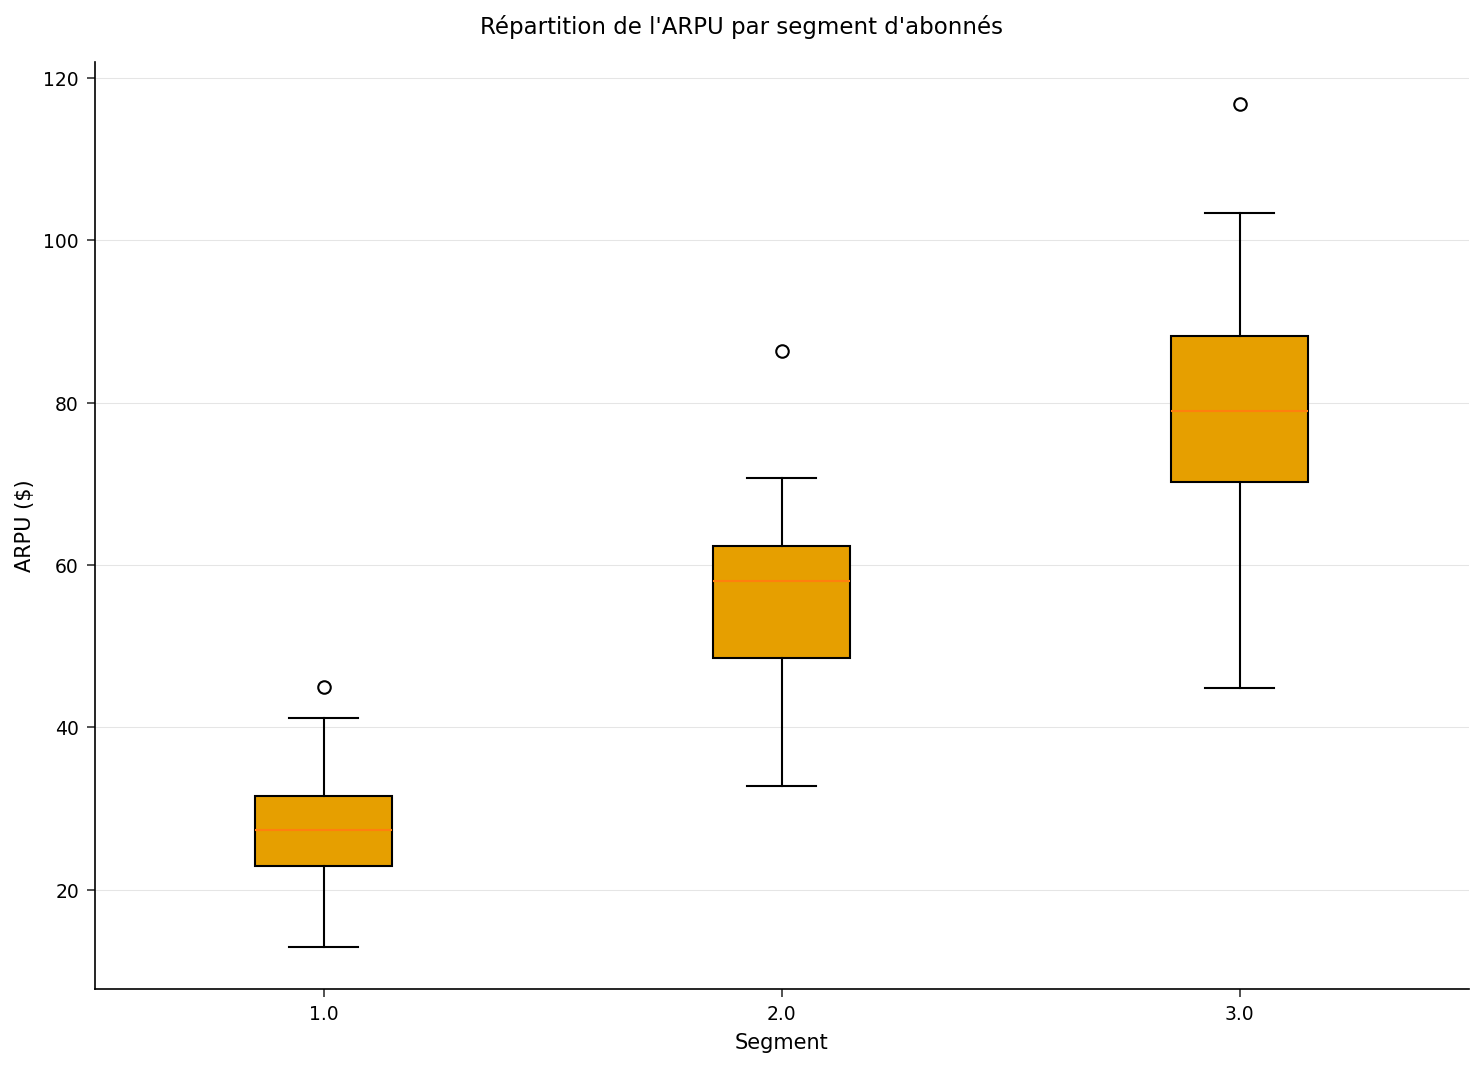

In [7]:
ODS GRAPHICS SUR / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Behavioral map: data vs. voice, colored by segment */
PROCÉDURE SGPLOT DONNÉES=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUPE=cluster
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS ÉTIQUETTE="Données mensuelles (Go)" grid;
    YAXIS ÉTIQUETTE="Minutes voix"     grid;
    TITRE "Carte du comportement des abonnés par segment";
EXÉCUTER;

/* Revenue distribution per segment */
PROCÉDURE SGPLOT DONNÉES=profile;
    VBOX arpu / category=cluster;
    XAXIS ÉTIQUETTE="Segment";
    YAXIS ÉTIQUETTE="ARPU ($)" grid;
    TITRE "Répartition de l'ARPU par segment d'abonnés";
EXÉCUTER;

## 8. Exporter les segments notés

Enfin, transmettons les affectations aux systèmes CRM et de campagne en aval. Nous conservons l'identifiant, l'étiquette de segment, et les principales variables comportementales.

In [8]:
/* Persist the segment assignments for activation */
DONNÉES subscriber_segments;
    DÉFINIR profile;
    GARDER subscriber_id cluster tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=subscriber_segments(obs=10) noobs;
    ÉTIQUETTE subscriber_id   = "ID Abonné"
          cluster          = "Segment"
          tenure_months    = "Ancienneté (mois)"
          monthly_data_gb  = "Données mensuelles (Go)"
          voice_minutes    = "Minutes voix"
          arpu             = "ARPU ($)"
          data_plan        = "Forfait"
          region           = "Région";
    TITRE "Échantillon des segments d'abonnés notés";
EXÉCUTER;

                                        Échantillon des segments d'abonnés notés                                        

 ID Abonné  Segment   Ancienneté (mois)   Données mensuelles (Go)  Minutes voix  ARPU ($)    Forfait   Région
    100001        1                  30                       2.3           104        28  Prépayé    Sud
    100002        2                   8                      10.2           581     57.78  Prépayé    Ouest
    100003        2                   8                      10.7           385     55.66  Postpayé   Nord
    100004        2                  68                       7.4           561     70.68  Prépayé    Nord
    100005        3                  18                      45.6           239     63.85  Illimité   Nord
    100006        3                  10                      30.1           249     88.33  Illimité   Est
    100007        1                  62                       0.7            83     21.26  Prépayé    Sud
    100008        1  


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interprétation des résultats

`PROC FASTCLUS` a récupéré trois segments propres et bien séparés. L'ajustement est solide : le **R-carré global est de 0.575** et le **pseudo-F est de 65.75**, ce qui signifie que les trois segments expliquent environ 58 % de la variation totale dans les variables standardisées. La séparation est portée presque entièrement par les signaux comportementaux qui nous intéressent -- `voice_minutes` (R-carré 0.858), `monthly_data_gb` (0.844), et `arpu` (0.771) portent la segmentation, tandis que `tenure_months` (0.000) et `support_calls` (0.193) ne contribuent presque rien, confirmant que c'est *comment* un abonné utilise le réseau -- et non depuis combien de temps il est client -- qui définit les personas.

Les trois segments correspondent directement à des personas prêts pour le marketing, profilés ici à l'échelle originale (non standardisée) :

| Segment | n (part) | Comportement caractéristique | Mélange de forfaits | Persona | Action recommandée |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Plus forte donnée : **44.4 Go/mois**, plus forte dépense **79.1 $ ARPU**, voix modeste (205 min) | 24/30 **Illimité** | **Streamers forte donnée** | Protéger et vendre en complément : forfaits plus rapides, offres de contenu, mises à niveau d'appareil |
| **2** | 34 (34%) | Plus forte voix **603 min/mois**, **214 SMS**, **106 min internationales**, dépense moyenne **55.9 $ ARPU** | Prépayé + Postpayé, **aucun Illimité** | **Traditionalistes centrés voix** | Options internationales, forfaits famille/voix, récompenses de fidélité |
| **1** | 36 (36%) | Plus faible usage : **4.0 Go**, 104 min voix, plus faible dépense **28.0 $ ARPU** | 25/36 **Prépayé** | **Léger / faible usage** | Ajuster la taille des forfaits, incitations au prélèvement automatique, forfaits de données d'entrée de gamme pour faire croître l'usage |

Le mélange de forfaits corrobore la lecture comportementale : le segment forte donnée est très majoritairement sur des forfaits **Illimité** (24 sur 30), le segment centré voix ne détient **aucun** abonné Illimité, et le segment faible usage est majoritairement **Prépayé** (25 sur 36). La région, en revanche, est répartie uniformément entre les trois segments -- la géographie n'est pas un facteur comportemental ici, ce qui est en soi un résultat utile pour le ciblage des campagnes.

**Pourquoi `PROC FASTCLUS` convient à ce problème.** Elle exécute un k-means disjoint en parcourant les données plutôt qu'en matérialisant une matrice de distance complète, donc le même programme qui a segmenté ces 100 abonnés passe à l'échelle sur de très grandes bases. Standardiser d'abord avec `PROC STDIZE` a supprimé le biais d'échelle des unités entre gigaoctets, minutes et dollars afin que chaque comportement contribue également à la distance euclidienne ; les diagnostics de R-carré ont ensuite indiqué *quelles* variables ont réellement déterminé la séparation. La sortie notée -- une étiquette `CLUSTER` pour chaque abonné -- s'intègre directement dans les pipelines d'activation, bouclant la boucle du comportement brut à l'offre ciblée.

---

<div style="font-size:11px;color:#9e9e9e">Ce notebook est fourni à des fins de démonstration uniquement. Les données sont synthétiques et les résultats ne constituent pas un conseil commercial.</div>